<a href="https://colab.research.google.com/github/otikuoY/texas-education-opportunity-data-analysis/blob/main/notebooks/final_texas_education_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Private School Access and Education Opportunity in Texas

This notebook analyzes how private-school access varies across Texas counties and how it relates to income, poverty, and adult education level.

The main access metric is:

> private schools per 100,000 people

This project uses Python, pandas, matplotlib, and statsmodels.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

base = "/content/drive/MyDrive/nyu-data-project"

print("Setup complete.")

Mounted at /content/drive
Setup complete.


In [2]:
# Load private school data
private = pd.read_csv(
    base + "/data/raw/private_schools_raw.csv",
    low_memory=False
)

print("Private school raw data shape:", private.shape)
private.head()

Private school raw data shape: (22345, 459)


,PFNLWT,REPW1,REPW2,REPW3,REPW4,REPW5,REPW6,REPW7,REPW8,REPW9,...,S1_F_P610,S1_F_P620,S1_F_P622,S1_F_P630,S1_F_P635,S1_F_P640,S1_F_P645,S1_F_P650,S1_F_P655,S1_F_P660
0,1.050000,1.050000,1.050000,1.050000,1.050000,1.050000,1.050000,1.050000,1.050000,1.050000,...,0,0,0,0,0,0,0,0,0,0
1,1.227273,1.227273,1.227273,1.227273,1.227273,1.227273,1.227273,1.227273,1.227273,1.227273,...,0,0,0,0,0,0,0,0,0,0
2,1.231884,1.231884,1.231884,1.231884,1.231884,1.231884,1.231884,1.231884,1.231884,1.231884,...,0,0,0,0,0,0,0,0,0,0
3,1.155844,1.155844,1.155844,1.155844,1.155844,1.155844,1.155844,1.155844,1.155844,1.155844,...,0,0,0,0,0,0,0,0,0,0
4,1.176471,1.176471,1.176471,1.176471,1.176471,1.176471,1.176471,1.176471,1.176471,1.176471,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Clean private school data

private_tx = private[private["PSTABB"] == "TX"].copy()

needed_cols = [
    "PINST",       # school name
    "PSTABB",      # state
    "PCNTNM",      # county
    "PCITY",       # city
    "PZIP",        # zip code
    "NUMSTUDS",    # total students
    "NUMTEACH",    # teachers FTE
    "STTCH_RT",    # student-teacher ratio
    "RELIG",       # religious affiliation
    "LEVEL3"       # school level
]

cols_to_use = [col for col in needed_cols if col in private_tx.columns]

private_clean = private_tx[cols_to_use].copy()

private_clean = private_clean.rename(columns={
    "PINST": "school_name",
    "PSTABB": "state",
    "PCNTNM": "county",
    "PCITY": "city",
    "PZIP": "zip_code",
    "NUMSTUDS": "students",
    "NUMTEACH": "teachers_fte",
    "STTCH_RT": "student_teacher_ratio",
    "RELIG": "religion_code",
    "LEVEL3": "school_level_code"
})

private_clean["county"] = (
    private_clean["county"]
    .astype(str)
    .str.lower()
    .str.strip()
)

private_clean["city"] = (
    private_clean["city"]
    .astype(str)
    .str.title()
    .str.strip()
)

numeric_cols = ["students", "teachers_fte", "student_teacher_ratio"]

for col in numeric_cols:
    if col in private_clean.columns:
        private_clean[col] = pd.to_numeric(private_clean[col], errors="coerce")

print("Texas private school data shape:", private_clean.shape)

private_clean.head()

Texas private school data shape: (1309, 10)


,school_name,state,county,city,zip_code,students,teachers_fte,student_teacher_ratio,religion_code,school_level_code
5185,ST PHILIP THE APOSTLE CATHOLIC SCHOOL,TX,wharton,El Campo,77437,212,22.1,9.592760,1,1
5186,SACRED HEART SCHOOL,TX,wilson,Floresville,78114,49,4.0,12.250000,1,1
5187,ST MARY'S ELEMENTARY SCHOOL,TX,gillespie,Fredericksburg,78624,286,23.1,12.380952,1,1
5188,NOTRE DAME CATHOLIC SCHOOL,TX,kerr,Kerrville,78028,115,14.0,8.214286,1,1
5189,SS PETER & PAUL CATHOLIC SCHOOL,TX,comal,New Braunfels,78130,288,27.0,10.666667,1,1


In [4]:
# Create county-level private school summary

private_county = private_clean.groupby("county").agg(
    private_school_count=("school_name", "count"),
    private_enrollment=("students", "sum"),
    private_teachers_fte=("teachers_fte", "sum"),
    avg_student_teacher_ratio=("student_teacher_ratio", "mean")
).reset_index()

private_county["private_student_teacher_ratio"] = (
    private_county["private_enrollment"] / private_county["private_teachers_fte"]
)

print("County-level private school summary shape:", private_county.shape)

private_county.sort_values(
    "private_school_count",
    ascending=False
).head(10)

County-level private school summary shape: (121, 6)


,county,private_school_count,private_enrollment,private_teachers_fte,avg_student_teacher_ratio,private_student_teacher_ratio
51,harris,232,42028,4845.3,7.922469,8.673973
28,dallas,149,28733,3606.4,8.664596,7.967225
105,travis,85,13738,1840.8,7.108204,7.463060
101,tarrant,85,14323,1710.5,8.085999,8.373575
10,bexar,82,15682,1493.9,9.185705,10.497356
23,collin,68,12861,1082.7,11.905970,11.878637
39,fort bend,54,3637,445.1,7.608450,8.171197
30,denton,34,5963,634.6,8.453369,9.396470
34,el paso,32,3994,428.4,9.504159,9.323063
85,montgomery,30,4130,420.9,9.779022,9.812307


In [5]:
# Load Census ACS county-level data for Texas

import requests

url = "https://api.census.gov/data/2022/acs/acs5"

params = {
    "get": "NAME,B01003_001E,B19013_001E,B17001_001E,B17001_002E,B15003_001E,B15003_022E,B15003_023E,B15003_024E,B15003_025E",
    "for": "county:*",
    "in": "state:48"
}

response = requests.get(url, params=params)
data = response.json()

census = pd.DataFrame(data[1:], columns=data[0])

census = census.rename(columns={
    "NAME": "county_full",
    "B01003_001E": "population",
    "B19013_001E": "median_income",
    "B17001_001E": "poverty_total",
    "B17001_002E": "poverty_count",
    "B15003_001E": "education_total",
    "B15003_022E": "bachelors",
    "B15003_023E": "masters",
    "B15003_024E": "professional_degree",
    "B15003_025E": "doctorate"
})

numeric_cols = [
    "population",
    "median_income",
    "poverty_total",
    "poverty_count",
    "education_total",
    "bachelors",
    "masters",
    "professional_degree",
    "doctorate"
]

for col in numeric_cols:
    census[col] = pd.to_numeric(census[col], errors="coerce")

census["county"] = (
    census["county_full"]
    .str.replace(" County, Texas", "", regex=False)
    .str.lower()
    .str.strip()
)

census["poverty_rate"] = (
    census["poverty_count"] / census["poverty_total"] * 100
)

census["bachelors_or_higher"] = (
    census["bachelors"]
    + census["masters"]
    + census["professional_degree"]
    + census["doctorate"]
)

census["bachelors_or_higher_pct"] = (
    census["bachelors_or_higher"] / census["education_total"] * 100
)

census_clean = census[[
    "county",
    "population",
    "median_income",
    "poverty_rate",
    "bachelors_or_higher_pct"
]].copy()

print("Census county data shape:", census_clean.shape)

census_clean.head()

Census county data shape: (254, 5)


,county,population,median_income,poverty_rate,bachelors_or_higher_pct
0,anderson,58077,57445,15.633512,13.111509
1,andrews,18362,86458,11.941854,19.695735
2,angelina,86608,57055,16.099911,18.649716
3,aransas,24048,58168,17.871139,24.166929
4,archer,8649,69954,12.285814,25.174014


In [6]:
# Merge Census data with private school county summary

all_counties = census_clean.merge(
    private_county,
    on="county",
    how="left"
)

# Fill counties with no private schools as 0
zero_fill_cols = [
    "private_school_count",
    "private_enrollment",
    "private_teachers_fte",
    "avg_student_teacher_ratio",
    "private_student_teacher_ratio"
]

for col in zero_fill_cols:
    all_counties[col] = all_counties[col].fillna(0)

# Create access metrics
all_counties["private_schools_per_100k"] = (
    all_counties["private_school_count"] / all_counties["population"] * 100000
)

all_counties["private_enrollment_per_100k"] = (
    all_counties["private_enrollment"] / all_counties["population"] * 100000
)

print("Merged county dataset shape:", all_counties.shape)

all_counties.head()

Merged county dataset shape: (254, 12)


,county,population,median_income,poverty_rate,bachelors_or_higher_pct,private_school_count,private_enrollment,private_teachers_fte,avg_student_teacher_ratio,private_student_teacher_ratio,private_schools_per_100k,private_enrollment_per_100k
0,anderson,58077,57445,15.633512,13.111509,1.0,81.0,11.6,6.982759,6.982759,1.721852,139.470014
1,andrews,18362,86458,11.941854,19.695735,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
2,angelina,86608,57055,16.099911,18.649716,3.0,186.0,35.0,5.006072,5.314286,3.463883,214.760761
3,aransas,24048,58168,17.871139,24.166929,2.0,119.0,13.6,8.655844,8.750000,8.316700,494.843646
4,archer,8649,69954,12.285814,25.174014,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000


In [7]:
# Correlation analysis

analysis_all = all_counties.replace([np.inf, -np.inf], np.nan).dropna(
    subset=[
        "median_income",
        "poverty_rate",
        "bachelors_or_higher_pct",
        "private_schools_per_100k",
        "population"
    ]
).copy()

larger_counties = analysis_all[analysis_all["population"] >= 50000].copy()

corr_all = analysis_all["median_income"].corr(
    analysis_all["private_schools_per_100k"]
)

corr_large = larger_counties["median_income"].corr(
    larger_counties["private_schools_per_100k"]
)

corr_poverty = larger_counties["poverty_rate"].corr(
    larger_counties["private_schools_per_100k"]
)

corr_education = larger_counties["bachelors_or_higher_pct"].corr(
    larger_counties["private_schools_per_100k"]
)

print("All Texas counties income correlation:", round(corr_all, 3))
print("Population 50,000+ income correlation:", round(corr_large, 3))
print("Population 50,000+ poverty correlation:", round(corr_poverty, 3))
print("Population 50,000+ adult education correlation:", round(corr_education, 3))
print("Number of counties with population 50,000+:", larger_counties.shape[0])

All Texas counties income correlation: 0.039
Population 50,000+ income correlation: 0.284
Population 50,000+ poverty correlation: -0.151
Population 50,000+ adult education correlation: 0.446
Number of counties with population 50,000+: 69


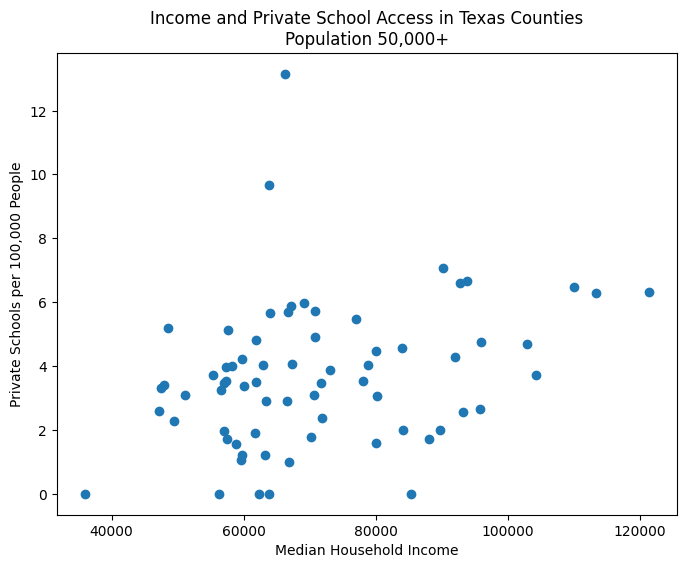

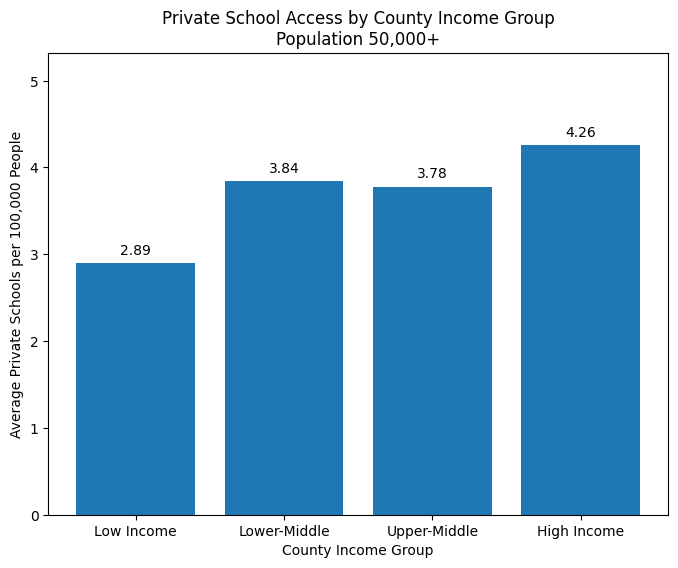

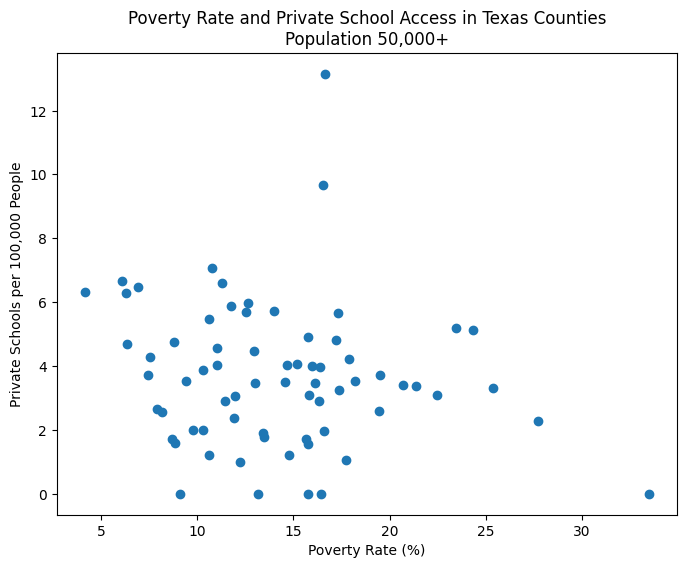

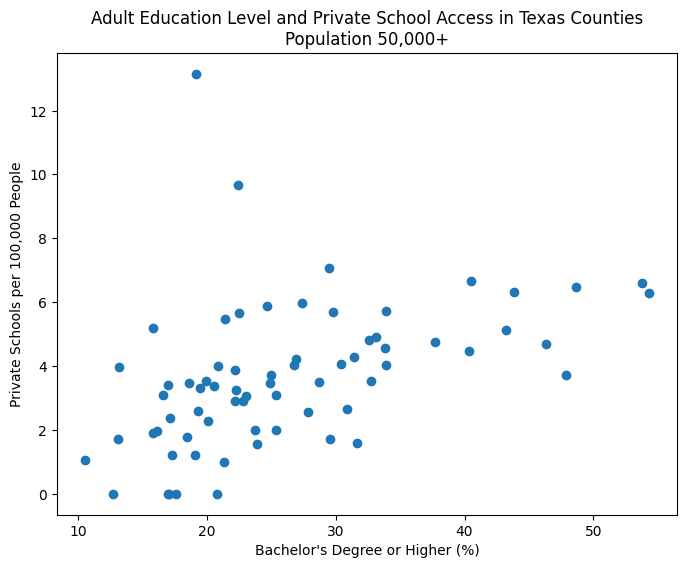

Saved all visualization charts.


In [8]:
# Visualizations

os.makedirs(base + "/charts", exist_ok=True)

# 1. Median income vs private school access
plt.figure(figsize=(8, 6))
plt.scatter(
    larger_counties["median_income"],
    larger_counties["private_schools_per_100k"]
)
plt.xlabel("Median Household Income")
plt.ylabel("Private Schools per 100,000 People")
plt.title("Income and Private School Access in Texas Counties\nPopulation 50,000+")
plt.savefig(
    base + "/charts/income_vs_private_school_access_population_50000_plus.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 2. Private school access by income group
larger_counties["income_group"] = pd.qcut(
    larger_counties["median_income"],
    q=4,
    labels=["Low Income", "Lower-Middle", "Upper-Middle", "High Income"]
)

income_group_summary = larger_counties.groupby(
    "income_group",
    observed=False
)["private_schools_per_100k"].mean().reset_index()

plt.figure(figsize=(8, 6))
plt.bar(
    income_group_summary["income_group"],
    income_group_summary["private_schools_per_100k"]
)
plt.xlabel("County Income Group")
plt.ylabel("Average Private Schools per 100,000 People")
plt.title("Private School Access by County Income Group\nPopulation 50,000+")

plt.ylim(0, income_group_summary["private_schools_per_100k"].max() * 1.25)

for i, value in enumerate(income_group_summary["private_schools_per_100k"]):
    plt.text(i, value + 0.1, round(value, 2), ha="center")

plt.savefig(
    base + "/charts/private_school_access_by_income_group.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 3. Poverty rate vs private school access
plt.figure(figsize=(8, 6))
plt.scatter(
    larger_counties["poverty_rate"],
    larger_counties["private_schools_per_100k"]
)
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Private Schools per 100,000 People")
plt.title("Poverty Rate and Private School Access in Texas Counties\nPopulation 50,000+")
plt.savefig(
    base + "/charts/poverty_vs_private_school_access.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# 4. Adult education level vs private school access
plt.figure(figsize=(8, 6))
plt.scatter(
    larger_counties["bachelors_or_higher_pct"],
    larger_counties["private_schools_per_100k"]
)
plt.xlabel("Bachelor's Degree or Higher (%)")
plt.ylabel("Private Schools per 100,000 People")
plt.title("Adult Education Level and Private School Access in Texas Counties\nPopulation 50,000+")
plt.savefig(
    base + "/charts/education_vs_private_school_access.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Saved all visualization charts.")

In [9]:
# Regression analysis

reg_df = larger_counties[[
    "private_schools_per_100k",
    "median_income",
    "poverty_rate",
    "bachelors_or_higher_pct",
    "population"
]].replace([np.inf, -np.inf], np.nan).dropna().copy()

reg_df["median_income_10k"] = reg_df["median_income"] / 10000
reg_df["log_population"] = np.log(reg_df["population"])

X = reg_df[[
    "median_income_10k",
    "poverty_rate",
    "bachelors_or_higher_pct",
    "log_population"
]]

X = sm.add_constant(X)
y = reg_df["private_schools_per_100k"]

model = sm.OLS(y, X).fit()

print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     private_schools_per_100k   R-squared:                       0.212
Model:                                  OLS   Adj. R-squared:                  0.163
Method:                       Least Squares   F-statistic:                     4.313
Date:                      Sun, 10 May 2026   Prob (F-statistic):            0.00376
Time:                              23:15:17   Log-Likelihood:                -145.67
No. Observations:                        69   AIC:                             301.3
Df Residuals:                            64   BIC:                             312.5
Df Model:                                 4                                         
Covariance Type:                  nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

## Key Takeaways

This analysis found that private-school access is not explained well by income alone.

Across all Texas counties, median household income had almost no correlation with private-school access. Among counties with populations above 50,000, income had a weak positive relationship with private-school access, while poverty rate had a weak negative relationship.

The strongest relationship was with adult education level. Counties with higher percentages of adults holding bachelor's degrees or higher tended to have more private schools per 100,000 people.

In the regression model, bachelor's degree attainment was the only statistically significant predictor among the variables tested. Median income, poverty rate, and population were not statistically significant predictors.

This analysis shows association, not causation. County-level analysis can hide important differences within counties, and private-school access may also depend on religion, urbanization, local history, transportation, and family preferences.